# 04 - 道路网络生成

**目标**：在 haidian 边界内生成模拟的道路网络（网格模式）。

**算法**：
1. 基于边界矩形创建规则网格道路
2. 按间距分成不同等级（主干路/次干路/支路/慢行道）
3. 所有道路裁剪到边界内
4. 输出 LineString GeoDataFrame

**学习要点**：
- 道路网络生成模式
- 道路分级体系
- LineString 几何操作

In [1]:
import sys
sys.path.insert(0, '..')

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import LineString, Point, box
from shapely.ops import unary_union, transform
import pyproj

from src.projection import transform_geometry, CRS_4326, CRS_4548

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Load and transform boundary
gdf_all = gpd.read_file('../data/haidian-boundary.geojson')
site = gdf_all[gdf_all['id'] == 'PROV-SITE-001'].iloc[0]
boundary_4548 = transform_geometry(site.geometry, CRS_4326, CRS_4548)

minx, miny, maxx, maxy = boundary_4548.bounds
print(f'Boundary extent: X [{minx:.0f}, {maxx:.0f}], Y [{miny:.0f}, {maxy:.0f}]')
print(f'Width: {maxx-minx:.0f}m, Height: {maxy-miny:.0f}m')

Boundary extent: X [443594, 444968], Y [4422955, 4432678]
Width: 1374m, Height: 9723m


## Step 1: 生成道路网格

创建三组网格线（对应不同的间距=道路等级），然后裁剪到边界内。

| 等级 | 代码 | 间距 | 说明 |
|------|------|------|------|
| 次干道 | secondary | ~1200m | 城市次干路 |
| 支路 | branch | ~600m | 城市支路 |
| 慢行道 | slow | ~250m | 慢行专用道 |

In [3]:
def generate_grid_roads(boundary_poly, spacing_m, offset_m=0):
    """Generate grid lines at given spacing, clipped to boundary."""
    minx, miny, maxx, maxy = boundary_poly.bounds
    
    lines = []
    
    # Vertical lines (南北向)
    x = minx + offset_m
    while x <= maxx:
        line = LineString([(x, miny), (x, maxy)])
        clipped = line.intersection(boundary_poly)
        if not clipped.is_empty:
            if clipped.geom_type == 'LineString':
                lines.append(clipped)
            elif clipped.geom_type == 'MultiLineString':
                lines.extend(list(clipped.geoms))
        x += spacing_m
    
    # Horizontal lines (东西向)
    y = miny + offset_m
    while y <= maxy:
        line = LineString([(minx, y), (maxx, y)])
        clipped = line.intersection(boundary_poly)
        if not clipped.is_empty:
            if clipped.geom_type == 'LineString':
                lines.append(clipped)
            elif clipped.geom_type == 'MultiLineString':
                lines.extend(list(clipped.geoms))
        y += spacing_m
    
    return lines

In [4]:
# Generate three road classes
road_levels = [
    ('secondary', '次干道', 1200, 0, '#E57373'),
    ('branch', '支路', 600, 0, '#FFB74D'),
    ('slow', '慢行道', 250, 0, '#81C784'),
]

all_roads = []

for class_code, class_name, spacing, offset, color in road_levels:
    lines = generate_grid_roads(boundary_4548, spacing, offset)
    for line in lines:
        all_roads.append({
            'road_class': class_code,
            'road_name': class_name,
            'spacing_m': spacing,
            'geometry': line
        })

roads_gdf = gpd.GeoDataFrame(all_roads, crs='EPSG:4548')

print(f'Total road segments: {len(roads_gdf)}')
print()
for rc in ['secondary', 'branch', 'slow']:
    subset = roads_gdf[roads_gdf['road_class'] == rc]
    total_len = subset.geometry.length.sum()
    print(f'  {rc:12s}: {len(subset):3d} segments, total length: {total_len:,.0f}m')

Total road segments: 73

  secondary   :  10 segments, total length: 18,023m
  branch      :  19 segments, total length: 37,153m
  slow        :  44 segments, total length: 89,202m


In [5]:
# Compute road network density
total_road_length = roads_gdf.geometry.length.sum()
boundary_area_sqm = boundary_4548.area
boundary_area_km2 = boundary_area_sqm / 1_000_000
road_density = total_road_length / boundary_area_km2  # m/km²

print(f'=== Road Network Statistics ===')
print(f'Total road length: {total_road_length:,.0f} m = {total_road_length/1000:.2f} km')
print(f'Boundary area: {boundary_area_km2:.4f} km²')
print(f'Road density: {road_density:,.1f} m/km²')

# Typical benchmark: 5-8 km/km² for urban areas in China
density_km_per_km2 = road_density / 1000
print(f'Road density: {density_km_per_km2:.2f} km/km²')

=== Road Network Statistics ===
Total road length: 144,379 m = 144.38 km
Boundary area: 11.4128 km²
Road density: 12,650.6 m/km²
Road density: 12.65 km/km²


## Step 2: 可视化

/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_57663/1551256963.py:35: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from current font.
  plt.tight_layout()
/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_57663/1551256963.py:35: UserWarning: Glyph 25311 (\N{CJK UNIFIED IDEOGRAPH-62DF}) missing from current font.
  plt.tight_layout()
/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_57663/1551256963.py:35: UserWarning: Glyph 36947 (\N{CJK UNIFIED IDEOGRAPH-9053}) missing from current font.
  plt.tight_layout()
/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_57663/1551256963.py:35: UserWarning: Glyph 36335 (\N{CJK UNIFIED IDEOGRAPH-8DEF}) missing from current font.
  plt.tight_layout()
/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipykernel_57663/1551256963.py:35: UserWarning: Glyph 32593 (\N{CJK UNIFIED IDEOGRAPH-7F51}) missing from current font.
  plt.tight_layout()
/var/folders/kg/h3yy2nfx60b7k6s6qy9xq9vh0000gp/T/ipyker

/Volumes/innerdisk/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Volumes/innerdisk/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25311 (\N{CJK UNIFIED IDEOGRAPH-62DF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Volumes/innerdisk/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36947 (\N{CJK UNIFIED IDEOGRAPH-9053}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Volumes/innerdisk/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36335 (\N{CJK UNIFIED IDEOGRAPH-8DEF}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Volumes/innerdisk/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32593 (\N{CJK UNIFIED I

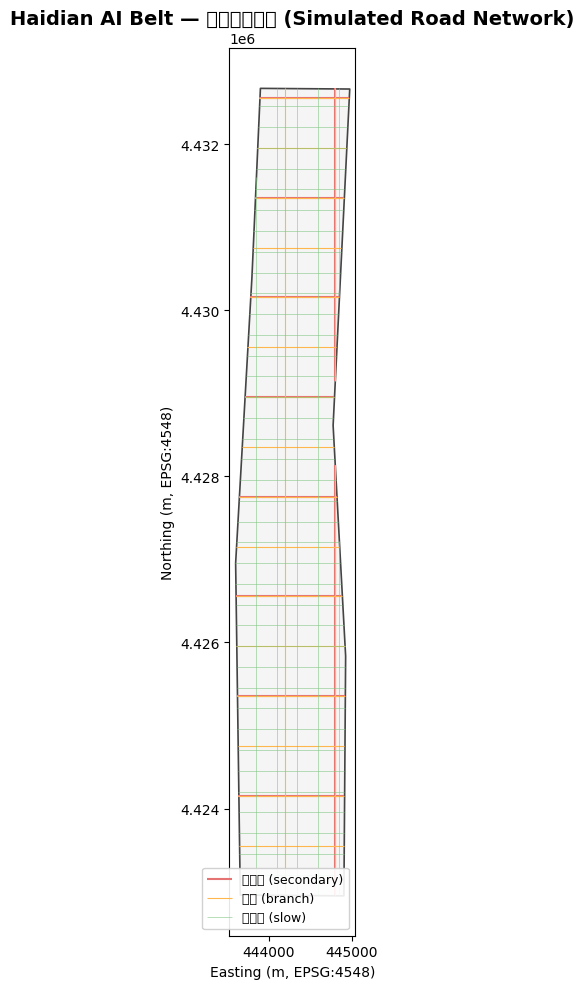

In [6]:
ROAD_COLORS = {
    'secondary': '#E57373',
    'branch': '#FFB74D',
    'slow': '#81C784',
}
ROAD_WIDTHS = {
    'secondary': 1.5,
    'branch': 0.8,
    'slow': 0.4,
}

fig, ax = plt.subplots(figsize=(14, 10))

# Boundary
gpd.GeoSeries([boundary_4548]).plot(
    ax=ax, facecolor='#F5F5F5', edgecolor='#444444', linewidth=1.2
)

# Roads by class
for rc in ['secondary', 'branch', 'slow']:
    subset = roads_gdf[roads_gdf['road_class'] == rc]
    label = subset['road_name'].iloc[0] if len(subset) > 0 else rc
    subset.plot(
        ax=ax,
        color=ROAD_COLORS[rc],
        linewidth=ROAD_WIDTHS[rc],
        label=f'{label} ({rc})'
    )

ax.set_title('Haidian AI Belt — 模拟道路网络 (Simulated Road Network)', fontsize=14, fontweight='bold')
ax.set_xlabel('Easting (m, EPSG:4548)')
ax.set_ylabel('Northing (m, EPSG:4548)')
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig('../outputs/road_network_preview.png', dpi=150, bbox_inches='tight')
plt.show()

## 总结

- 成功生成了三级道路网络（次干道 / 支路 / 慢行道）
- 所有道路段裁剪到边界内
- 计算了道路网密度指标
- 下一步：拓扑检查验证